In [1]:
pip install mediapipe==0.10.11


     ---------------------------------------- 0.0/50.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/50.8 MB ? eta -:--:--
     --------------------------------------- 0.0/50.8 MB 435.7 kB/s eta 0:01:57
     --------------------------------------- 0.0/50.8 MB 435.7 kB/s eta 0:01:57
     --------------------------------------- 0.0/50.8 MB 279.3 kB/s eta 0:03:02
     --------------------------------------- 0.1/50.8 MB 544.7 kB/s eta 0:01:34
     --------------------------------------- 0.1/50.8 MB 552.2 kB/s eta 0:01:32
     --------------------------------------- 0.2/50.8 MB 508.4 kB/s eta 0:01:40
     --------------------------------------- 0.2/50.8 MB 621.6 kB/s eta 0:01:22
     --------------------------------------- 0.2/50.8 MB 600.7 kB/s eta 0:01:25
     --------------------------------------- 0.3/50.8 MB 629.0 kB/s eta 0:01:21
     --------------------------------------- 0.3/50.8 MB 676.7 kB/s eta 0:01:15
     --------------------------------------- 0.4/50.8 M


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import argparse
import os


## Blure face (image)

(np.float64(-0.5), np.float64(711.5), np.float64(682.5), np.float64(-0.5))

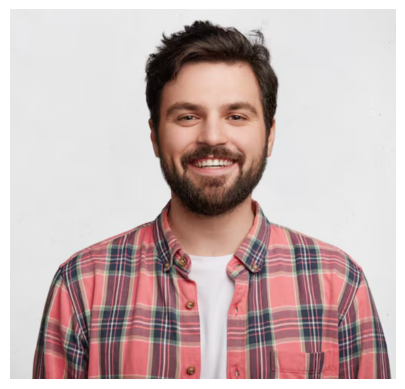

In [20]:
img_path = './data/person1.png'
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')


(np.float64(-0.5), np.float64(711.5), np.float64(682.5), np.float64(-0.5))

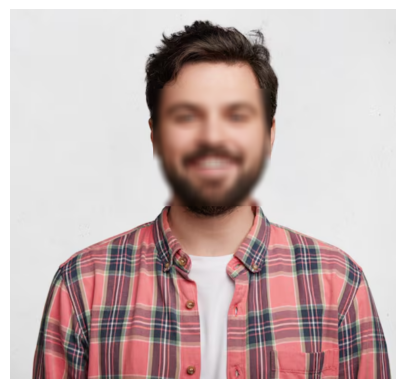

In [21]:
import cv2
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection

# تحويل الصورة لـ RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with mp_face_detection.FaceDetection(min_detection_confidence=0.5, model_selection=0) as face_detection:

    results = face_detection.process(img_rgb)

    if results.detections:  # check مهم
        for detection in results.detections:
            bboxC = detection.location_data.relative_bounding_box
            ih, iw, _ = img.shape

            x1 = int(bboxC.xmin * iw)
            y1 = int(bboxC.ymin * ih)
            w = int(bboxC.width * iw)
            h = int(bboxC.height * ih)

            x2 = x1 + w
            y2 = y1 + h

            # حماية من القيم السالبة
            x1, y1 = max(0, x1), max(0, y1)

            # رسم المستطيل
            # cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # blurring the face
            face_region = img[y1:y2, x1:x2]
            blurred_face = cv2.blur(face_region, (15, 15), 30)
            img[y1:y2, x1:x2] = blurred_face

plt.imshow(img)
plt.axis('off')

In [5]:
import mediapipe
print(mediapipe.__file__)
print(dir(mediapipe))

c:\Users\marwa\AppData\Local\Programs\Python\Python310\lib\site-packages\mediapipe\__init__.py
['CalculatorGraph', 'GraphInputStreamAddMode', 'Image', 'ImageFormat', 'ImageFrame', 'Matrix', 'Packet', 'Timestamp', 'ValidatedGraphConfig', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculators', 'packet_creator', 'packet_getter', 'resource_util', 'solutions', 'tasks']


In [22]:
# save image
output_path = './data/person1_blurred.png'
cv2.imwrite(output_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

True

## Blure face (video)

In [28]:
def process_img(img, face_detection):

    H, W, _ = img.shape

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    out = face_detection.process(img_rgb)

    if out.detections is not None:
        for detection in out.detections:
            location_data = detection.location_data
            bbox = location_data.relative_bounding_box

            x1, y1, w, h = bbox.xmin, bbox.ymin, bbox.width, bbox.height

            x1 = int(x1 * W)
            y1 = int(y1 * H)
            w = int(w * W)
            h = int(h * H)

            # print(x1, y1, w, h)

            # blur faces
            img[y1:y1 + h, x1:x1 + w, :] = cv2.blur(img[y1:y1 + h, x1:x1 + w, :], (30, 30))

    return img


In [ ]:
# ---------- ARGUMENTS ----------
args = argparse.ArgumentParser()
args.add_argument("--mode", default='webcam')   # image / video / webcam
args.add_argument("--filePath", default='./data/person1.png')
args = args.parse_args()

# ---------- OUTPUT DIR ----------
output_dir = './data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ---------- MEDIAPIPE ----------
mp_face_detection = mp.solutions.face_detection

with mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5) as face_detection:

    # ---------- IMAGE ----------
    if args.mode == "image":
        img = cv2.imread(args.filePath)

        img = process_img(img, face_detection)

        cv2.imwrite(os.path.join(output_dir, 'output.png'), img)
        print("✅ Image saved")

    # ---------- VIDEO ----------
    elif args.mode == "video":
        cap = cv2.VideoCapture(args.filePath)
        ret, frame = cap.read()

        if not ret:
            print("❌ Error reading video")
            exit()

        output_video = cv2.VideoWriter(
            os.path.join(output_dir, 'output.mp4'),
            cv2.VideoWriter_fourcc(*'MP4V'),
            25,
            (frame.shape[1], frame.shape[0])
        )

        while ret:
            frame = process_img(frame, face_detection)
            output_video.write(frame)

            ret, frame = cap.read()

        cap.release()
        output_video.release()
        print("✅ Video saved")

    # ---------- WEBCAM ----------
    elif args.mode == "webcam":
        cap = cv2.VideoCapture(0) 

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = process_img(frame, face_detection)

            cv2.imshow('frame', frame)

            # 🔥 خروج بـ q
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()

cv2.destroyAllWindows()